# Importing Primary Libraries

In [ ]:
import numpy as np 
import pandas as pd 

# Load Dataset

In [96]:
matches = pd.read_csv("../data/processed/matches.csv")

In [97]:
matches.info()

<class 'pandas.DataFrame'>
RangeIndex: 23500 entries, 0 to 23499
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   date                        23500 non-null  str    
 1   home_team                   23500 non-null  str    
 2   away_team                   23500 non-null  str    
 3   home_score                  23500 non-null  int64  
 4   away_score                  23500 non-null  int64  
 5   goal_diff                   23500 non-null  int64  
 6   tournament                  23500 non-null  str    
 7   country                     23500 non-null  str    
 8   neutral                     23500 non-null  bool   
 9   home_is_host                23500 non-null  int64  
 10  elo_diff                    23500 non-null  float64
 11  home_higher_elo             23500 non-null  int64  
 12  home_recent_win_rate        23500 non-null  float64
 13  away_recent_win_rate        23500 non-null

# Preparation

## Define features and target

In [98]:
feature_cols = [
    "neutral",
    "home_is_host",
    "elo_diff",
    "recent_form_diff",
    "diff_in_avg_goals",
    "diff_in_total_conceded",
    "tournament_weight"
]

target = "match_result"

X = matches[feature_cols]
y = matches[target]

# Train-test Split

In [99]:
matches["date"] = pd.to_datetime(matches["date"])
split_date = "2022-12-19"
train = matches[matches["date"] < split_date]
test = matches[matches["date"] >= split_date]

# Checking train-test split ratio
print(len(train)/len(matches)*100)

86.01702127659574


In [100]:
# Preparing train and test sets
X_train = train[feature_cols]
y_train = train[target]
X_test = test[feature_cols]
y_test = test[target]

print(f"Training set: {len(train)} matches")
print(f"Test set: {len(test)} matches")
print(f"\nTarget distribution:\n{y_train.value_counts(normalize=True)}")

Training set: 20214 matches
Test set: 3286 matches

Target distribution:
match_result
home_win    0.483427
away_win    0.279954
draw        0.236618
Name: proportion, dtype: float64


## Encoding

In [ ]:
# Encode target labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)  
print(f"\nLabel encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")


Label encoding: {'away_win': 0, 'draw': 1, 'home_win': 2}


# Model Training

## Logistic Regression

Logistic Regression serves as the baseline model for this prediction project.

In [ ]:
# Standardise the training and test data
from sklearn.preprocessing import StandardScaler
std_x = StandardScaler()
X_train = std_x.fit_transform(X_train)
X_test = std_x.transform(X_test)

In [ ]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import balanced_accuracy_score

lr = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)
print("\n--- Logistic Regression ---")
print(f"Accuracy: {accuracy_score(y_test, lr_preds):.4f}")
print(classification_report(y_test, lr_preds))
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, lr_preds):.4f}")


--- Logistic Regression ---
Accuracy: 0.5654
              precision    recall  f1-score   support

    away_win       0.56      0.65      0.60       974
        draw       0.29      0.25      0.26       774
    home_win       0.70      0.67      0.68      1538

    accuracy                           0.57      3286
   macro avg       0.51      0.52      0.52      3286
weighted avg       0.56      0.57      0.56      3286

Balanced Accuracy: 0.5233


## Random Forest

In [ ]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
print("\n--- Random Forest ---")
print(f"Accuracy: {accuracy_score(y_test, rf_preds):.4f}")
print(classification_report(y_test, rf_preds))
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, rf_preds):.4f}")


--- Random Forest ---
Accuracy: 0.5584
              precision    recall  f1-score   support

    away_win       0.55      0.54      0.54       974
        draw       0.28      0.13      0.18       774
    home_win       0.61      0.79      0.69      1538

    accuracy                           0.56      3286
   macro avg       0.48      0.48      0.47      3286
weighted avg       0.52      0.56      0.53      3286

Balanced Accuracy: 0.4850


## XGBoost

In [ ]:
# XGBoost
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric="mlogloss")
xgb.fit(X_train, y_train_encoded)
xgb_preds = le.inverse_transform(xgb.predict(X_test))
print("\n--- XGBoost ---")
print(f"Accuracy: {accuracy_score(y_test, xgb_preds):.4f}")
print(classification_report(y_test, xgb_preds))
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, xgb_preds):.4f}")


--- XGBoost ---
Accuracy: 0.5849
              precision    recall  f1-score   support

    away_win       0.57      0.59      0.58       974
        draw       0.22      0.04      0.06       774
    home_win       0.61      0.85      0.71      1538

    accuracy                           0.58      3286
   macro avg       0.47      0.50      0.45      3286
weighted avg       0.51      0.58      0.52      3286

Balanced Accuracy: 0.4954


In [ ]:
# Baseline model using DummyClassifier
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")

dummy.fit(X_train, y_train)

preds = dummy.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, preds):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, preds):.4f}")

Accuracy: 0.4680
Balanced Accuracy: 0.3333


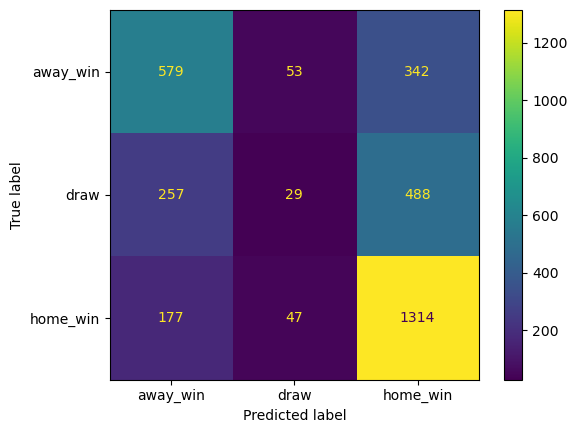

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test,xgb_preds)

In [113]:
pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

elo_diff                  0.397195
diff_in_total_conceded    0.215002
diff_in_avg_goals         0.208184
recent_form_diff          0.113922
tournament_weight         0.055082
neutral                   0.005312
home_is_host              0.005302
dtype: float64

In [108]:
pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

home_is_host              0.305213
elo_diff                  0.253778
neutral                   0.122785
diff_in_total_conceded    0.097488
tournament_weight         0.082599
recent_form_diff          0.070470
diff_in_avg_goals         0.067667
dtype: float32